## 7.1
Identify the number of support vectors in dependence of the parameter (λ, C, depending on the formulation) on a synthetic dataset, and on the titanic and breast cancer datasets. Repeat the problem with different kernels.

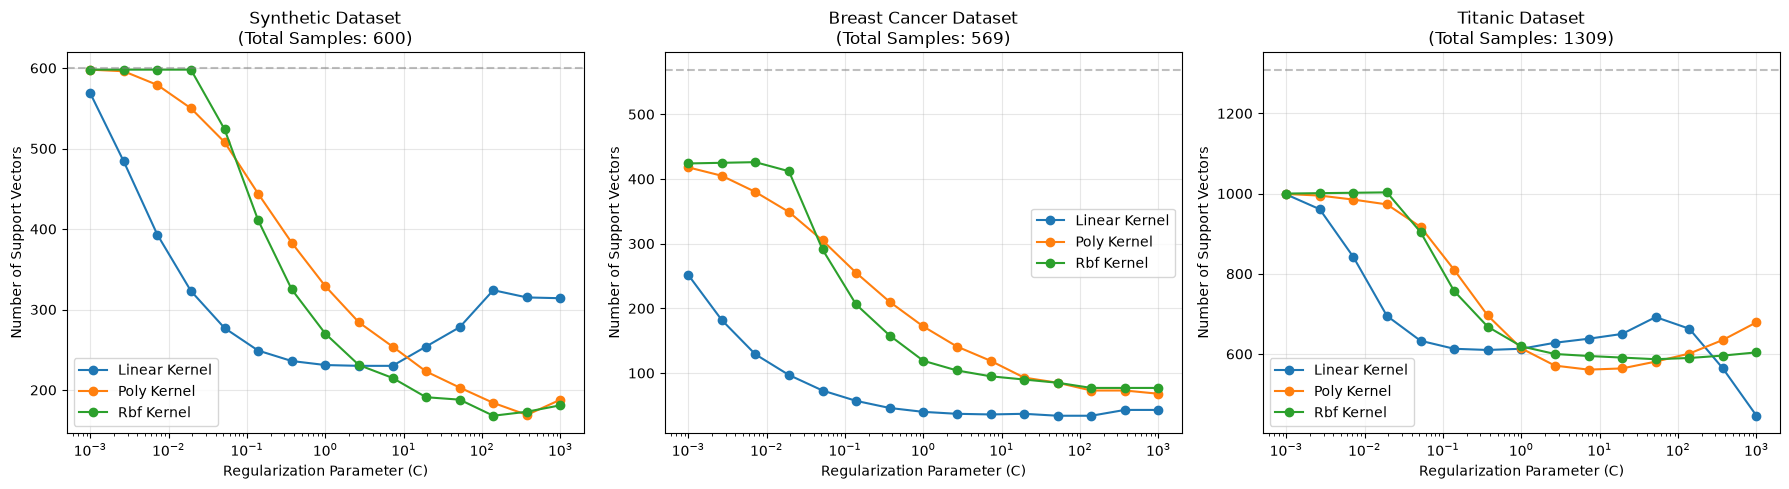

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification, load_breast_cancer, fetch_openml
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
import warnings

# Suppress minor warnings from fetch_openml or potential convergence limits
# warnings.filterwarnings('ignore')

def load_and_preprocess_data():
    """Loads and preprocesses the three datasets."""
    datasets = {}

    # 1. Synthetic Dataset
    X_syn, y_syn = make_classification(
        n_samples=600, n_features=10, n_informative=5, n_redundant=2, random_state=42
    )
    # Scale synthetic data
    X_syn = StandardScaler().fit_transform(X_syn)
    datasets['Synthetic'] = (X_syn, y_syn)

    # 2. Breast Cancer Dataset
    cancer = load_breast_cancer()
    X_canc = StandardScaler().fit_transform(cancer.data)
    datasets['Breast Cancer'] = (X_canc, cancer.target)

    # 3. Titanic Dataset
    titanic = fetch_openml('titanic', version=1, as_frame=True)
    df = titanic.frame
    
    # Drop columns with too much missing data or irrelevant string identifiers
    df = df.drop(columns=['name', 'ticket', 'cabin', 'boat', 'body', 'home.dest'])
    
    # Separate features and target
    X_tit = df.drop(columns=['survived'])
    y_tit = df['survived'].astype(int).values

    # Preprocessing pipeline for Titanic's mixed data types
    numeric_features = ['age', 'fare', 'sibsp', 'parch']
    numeric_transformer = make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler()
    )

    categorical_features = ['sex', 'embarked', 'pclass']
    categorical_transformer = make_pipeline(
        SimpleImputer(strategy='most_frequent'),
        OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )

    X_tit_processed = preprocessor.fit_transform(X_tit)
    datasets['Titanic'] = (X_tit_processed, y_tit)

    return datasets

def run_experiment():
    datasets = load_and_preprocess_data()
    
    # Define C values (logarithmic scale from 10^-3 to 10^3)
    C_values = np.logspace(-3, 3, 15)
    kernels = ['linear', 'poly', 'rbf']
    
    # Store results: results[dataset][kernel] = [list of SV counts]
    results = {name: {k: [] for k in kernels} for name in datasets.keys()}

    for dataset_name, (X, y) in datasets.items():
        for kernel in kernels:
            for C in C_values:
                # Initialize and fit SVC
                # Poly kernel defaults to degree=3
                clf = SVC(C=C, kernel=kernel, max_iter=10000, random_state=42)
                clf.fit(X, y)
                
                # Extract total number of support vectors
                n_sv = np.sum(clf.n_support_)
                results[dataset_name][kernel].append(n_sv)
                
    return datasets, C_values, kernels, results

def plot_results(datasets, C_values, kernels, results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
    
    for ax, dataset_name in zip(axes, datasets.keys()):
        total_samples = datasets[dataset_name][0].shape[0]
        
        for kernel in kernels:
            sv_counts = results[dataset_name][kernel]
            ax.plot(C_values, sv_counts, marker='o', label=f'{kernel.capitalize()} Kernel')
            
        ax.set_xscale('log')
        ax.set_title(f'{dataset_name} Dataset\n(Total Samples: {total_samples})')
        ax.set_xlabel('Regularization Parameter (C)')
        ax.set_ylabel('Number of Support Vectors')
        ax.grid(alpha=0.3)
        ax.legend()
        
        # Add a horizontal dashed line indicating the total number of samples
        ax.axhline(total_samples, color='gray', linestyle='--', alpha=0.5, label='Total Samples')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    datasets, C_values, kernels, results = run_experiment()
    plot_results(datasets, C_values, kernels, results)